# The Steam Marketplace, 2004–2018: Pricing, Popularity & Quality in 26,643 Games

**Final Individual Project — Data Visualization, Summer 2026**

This notebook analyzes fifteen years of games released on Steam — from the platform's
early days as a Valve-only storefront to the "indiepocalypse" era of thousands of annual
releases. Using pricing, estimated ownership, playtime, and critic reception, we ask how
the economics of PC gaming shifted as the market went from scarce and curated to abundant
and crowded.

**Dataset:** Steam Store + SteamSpy scrape, distributed via the R for Data Science
community's [TidyTuesday project](https://github.com/rfordatascience/tidytuesday/blob/master/data/2019/2019-07-30/readme.md)
(week of 2019-07-30). Real-world, non-synthetic, scraped directly from Steam/SteamSpy.

**Why this dataset satisfies "rich & varied":**
| Attribute type | Columns |
|---|---|
| Numerical | `price`, `average_playtime`, `median_playtime`, `metascore`, `owners_est` |
| Categorical | `developer`, `publisher`, `owners` (ordinal bracket), `price_tier` (engineered) |
| Temporal | `release_date`, `release_year`, `release_month` |
| Text | `game` (title) — analyzed for length, word count, sequel/edition patterns |

26,643 games remain after cleaning (2004–2018 full calendar years; rows with unparseable
dates dropped). Full cleaning logic lives in `data/clean_data.py`.


## 0. Setup

In [1]:
import sys
sys.path.append('.')
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from viz_style import (
    style_fig, OI_BLUE, OI_ORANGE, OI_GREEN, OI_VERMILLION, OI_PURPLE,
    OI_SKYBLUE, GREY, GREY_DARK, CATEGORY_SEQUENCE, set_default_renderer
)

set_default_renderer()
pd.set_option('display.max_columns', 50)

df = pd.read_csv('../data/video_games_clean.csv', parse_dates=['release_date_parsed'])
owner_order = [
    '0 .. 20,000', '20,000 .. 50,000', '50,000 .. 100,000', '100,000 .. 200,000',
    '200,000 .. 500,000', '500,000 .. 1,000,000', '1,000,000 .. 2,000,000',
    '2,000,000 .. 5,000,000', '5,000,000 .. 10,000,000', '10,000,000 .. 20,000,000',
    '20,000,000 .. 50,000,000', '50,000,000 .. 100,000,000', '100,000,000 .. 200,000,000'
]
df['owners'] = pd.Categorical(df['owners'], categories=owner_order, ordered=True)
tier_order = ['Free', 'Budget (<$5)', 'Mid ($5-15)', 'Standard ($15-30)', 'Premium ($30+)']
df['price_tier'] = pd.Categorical(df['price_tier'], categories=tier_order, ordered=True)

print(f"{len(df):,} games | {df['release_year'].min()}–{df['release_year'].max()}")
df.head(3)


26,643 games | 2004–2018


,number,game,release_date,price,owners,developer,publisher,average_playtime,median_playtime,metascore,release_date_parsed,release_year,release_month,release_month_name,owners_est,has_critic_score,price_tier,title_length_chars,title_word_count,is_sequel_like,developer_catalog_size,publisher_catalog_size,playtime_skew
0,1,Half-Life 2,"Nov 16, 2004",9.99,"10,000,000 .. 20,000,000",Valve,Valve,110.0,66.0,96.0,2004-11-16,2004,11,Nov,15000000.0,True,Mid ($5-15),11,2,True,22.0,22.0,0.400000
1,3,Counter-Strike: Source,"Nov 1, 2004",9.99,"10,000,000 .. 20,000,000",Valve,Valve,236.0,128.0,88.0,2004-11-01,2004,11,Nov,15000000.0,True,Mid ($5-15),22,2,False,22.0,22.0,0.457627
2,21,Counter-Strike: Condition Zero,"Mar 1, 2004",9.99,"10,000,000 .. 20,000,000",Valve,Valve,10.0,3.0,65.0,2004-03-01,2004,3,Mar,15000000.0,True,Mid ($5-15),30,3,False,22.0,22.0,0.700000


## 1. Preliminary Exploratory Data Analysis

A quick look at shape, missingness, and single-variable summaries before moving to the
analytical questions below. (These preliminary views are intentionally simple — the real
analysis starts in Section 2.)


In [2]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(1)
})
summary


,dtype,missing,missing_pct
number,int64,0,0.0
game,str,0,0.0
release_date,str,0,0.0
price,float64,0,0.0
owners,category,0,0.0
developer,str,151,0.6
publisher,str,120,0.5
average_playtime,float64,0,0.0
median_playtime,float64,0,0.0
metascore,float64,23803,89.3


In [3]:
print("Games per year:")
print(df['release_year'].value_counts().sort_index())
print()
print("Price summary ($):")
print(df['price'].describe().round(2))
print()
print(f"Games with a Metacritic score: {df['has_critic_score'].sum():,} ({df['has_critic_score'].mean()*100:.1f}%)")


Games per year:
release_year
2004      53
2005      58
2006     112
2007     143
2008     183
2009     330
2010     333
2011     364
2012     425
2013     556
2014    1348
2015    2540
2016    4498
2017    6861
2018    8839
Name: count, dtype: int64

Price summary ($):
count    26643.00
mean         7.91
std         11.80
min          0.00
25%          1.99
50%          4.99
75%          9.99
max        595.99
Name: price, dtype: float64

Games with a Metacritic score: 2,840 (10.7%)


## 2. Analytical Questions

Each question below combines at least two dimensions of the data (a numeric measure,
plus a category, a time axis, or a second numeric measure) and is answered with one
publication-ready Plotly figure.


### Q1 — As the Steam catalog exploded, did typical launch prices fall?

**Question:** How did the *volume* of yearly releases and the *median launch price*
move together between 2004 and 2018?


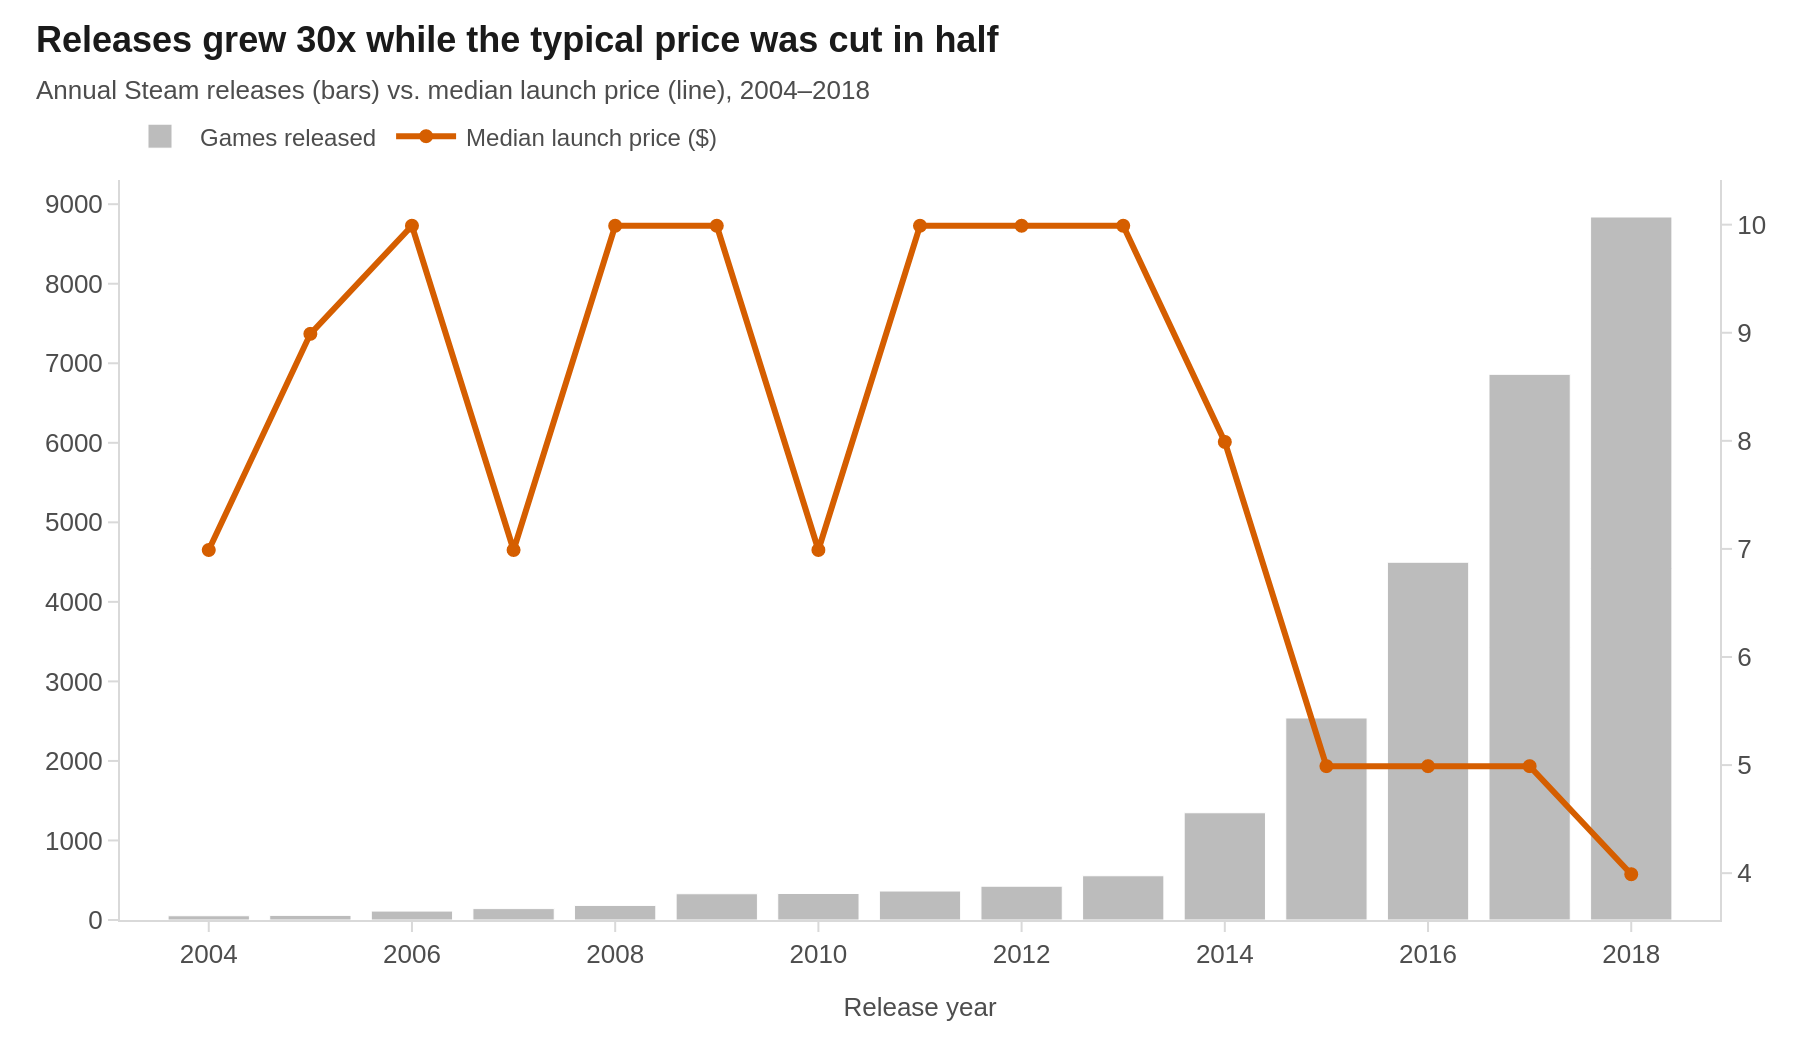

In [4]:
yearly = df.groupby('release_year').agg(
    releases=('game', 'count'),
    median_price=('price', 'median')
).reset_index()

fig = go.Figure()
fig.add_trace(go.Bar(
    x=yearly['release_year'], y=yearly['releases'],
    name='Games released', marker_color=GREY, opacity=0.85, yaxis='y1'
))
fig.add_trace(go.Scatter(
    x=yearly['release_year'], y=yearly['median_price'],
    name='Median launch price ($)', mode='lines+markers',
    line=dict(color=OI_VERMILLION, width=3), marker=dict(size=7), yaxis='y2'
))
fig.update_layout(
    yaxis=dict(title='Games released per year', side='left'),
    yaxis2=dict(title='Median price (USD)', overlaying='y', side='right', showgrid=False),
)
fig = style_fig(
    fig,
    title="Releases grew 30x while the typical price was cut in half",
    subtitle="Annual Steam releases (bars) vs. median launch price (line), 2004–2018",
    xaxis_title="Release year", show_grid_y=False
)
fig.show()


**Insight:** Annual releases grew from a few dozen titles in the mid-2000s to several
thousand by 2018 — driven by Steam Greenlight/Direct opening the platform to indie
developers. Median launch price fell from roughly $10–15 to under $6, reflecting a shift
toward smaller, cheaper indie titles rather than fewer, pricier boxed releases.


### Q2 — Did release seasonality change as the catalog matured?

**Question:** Is there still a "holiday launch window," or has month-of-release become
flatter as thousands of small studios release year-round?


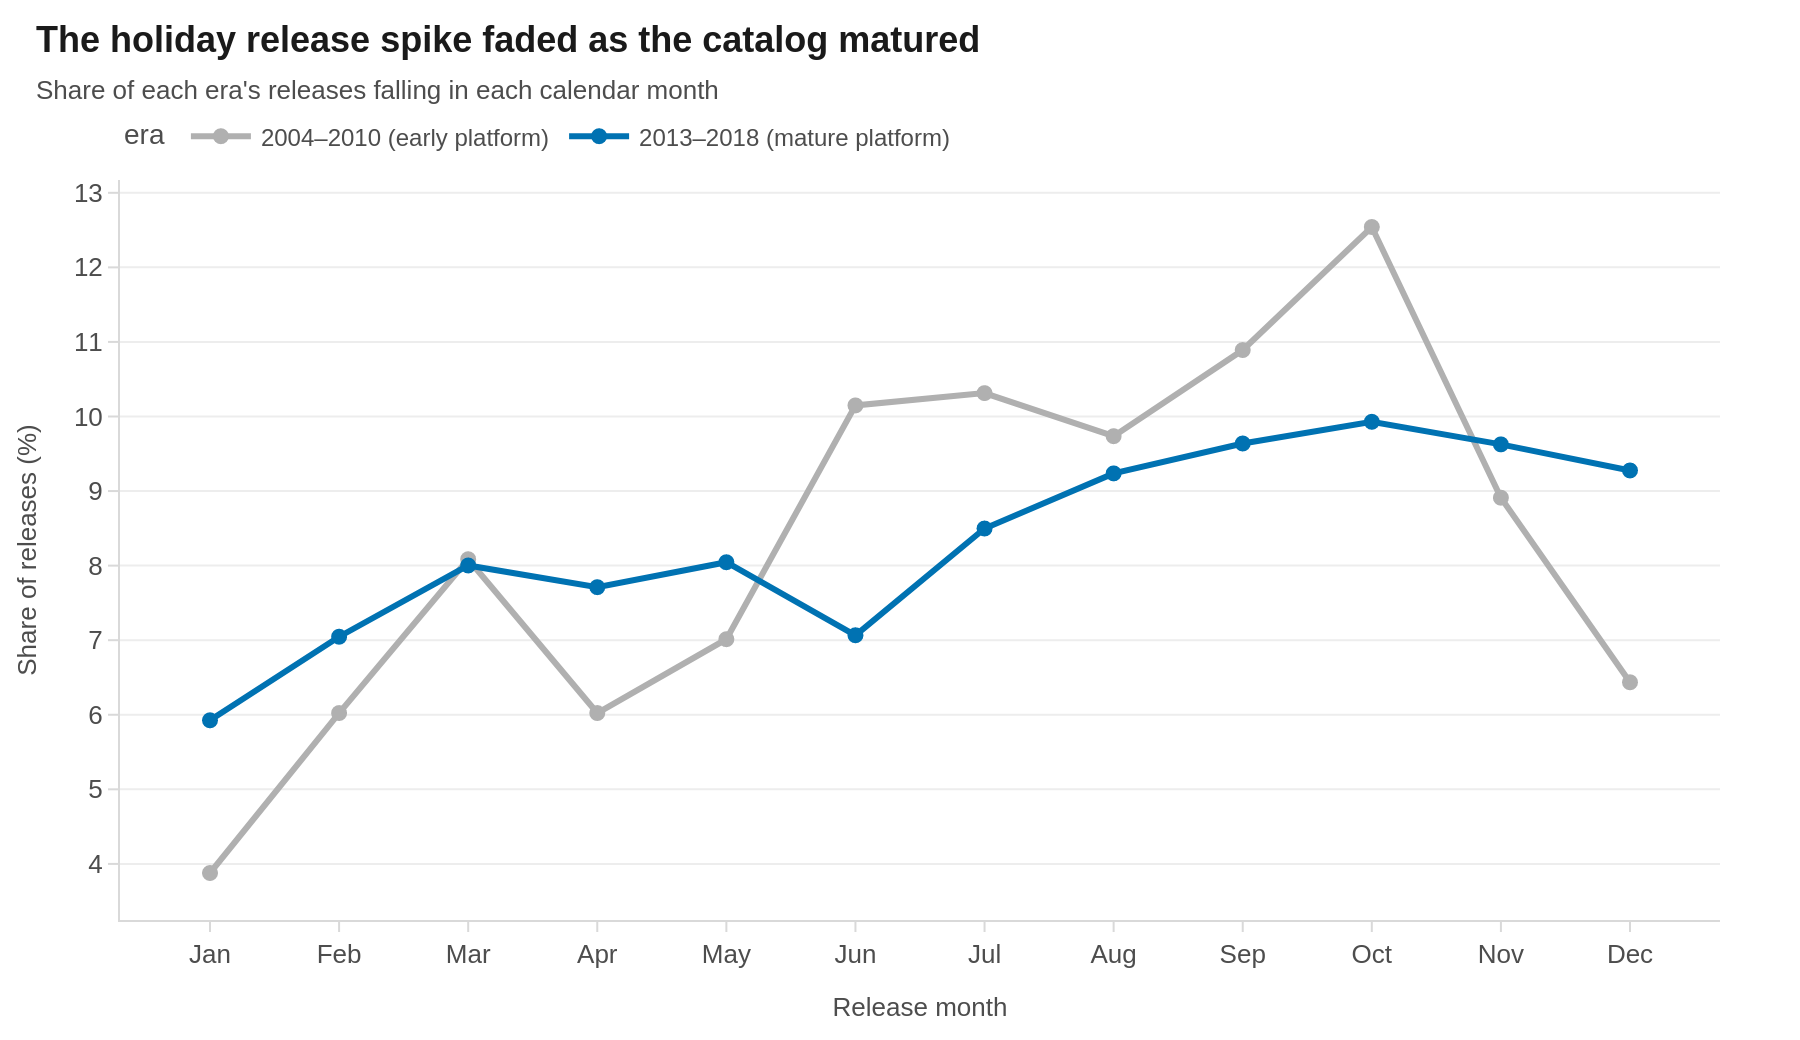

In [5]:
era_map = {y: ('2004–2010 (early platform)' if y <= 2010 else '2013–2018 (mature platform)')
           for y in range(2004, 2019)}
df['era'] = df['release_year'].map(era_map)
seasonal = df.dropna(subset=['era']).groupby(['era', 'release_month']).size().reset_index(name='count')
seasonal['share'] = seasonal.groupby('era')['count'].transform(lambda s: s / s.sum() * 100)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonal['month_name'] = seasonal['release_month'].apply(lambda m: month_names[m-1])

fig = px.line(
    seasonal, x='month_name', y='share', color='era', markers=True,
    category_orders={'month_name': month_names, 'era': ['2004–2010 (early platform)', '2013–2018 (mature platform)']},
    color_discrete_sequence=[GREY, OI_BLUE]
)
fig.update_traces(line=dict(width=3), marker=dict(size=8))
fig = style_fig(
    fig,
    title="The holiday release spike faded as the catalog matured",
    subtitle="Share of each era's releases falling in each calendar month",
    xaxis_title="Release month", yaxis_title="Share of releases (%)"
)
fig.show()


**Insight:** In 2004–2010, releases clustered noticeably toward Q4 (a classic retail
holiday-launch pattern). By 2013–2018 the curve is far flatter — with thousands of indie
titles launching continuously, the seasonal advantage of a holiday launch window has
largely dissolved for the median release (it still matters for AAA titles, which are a
small share of this catalog).


### Q3 — Is playtime driven by price, by popularity, or both?

**Question:** Controlling for how many people own a game, does a higher price tier
buy more player engagement (average playtime)?


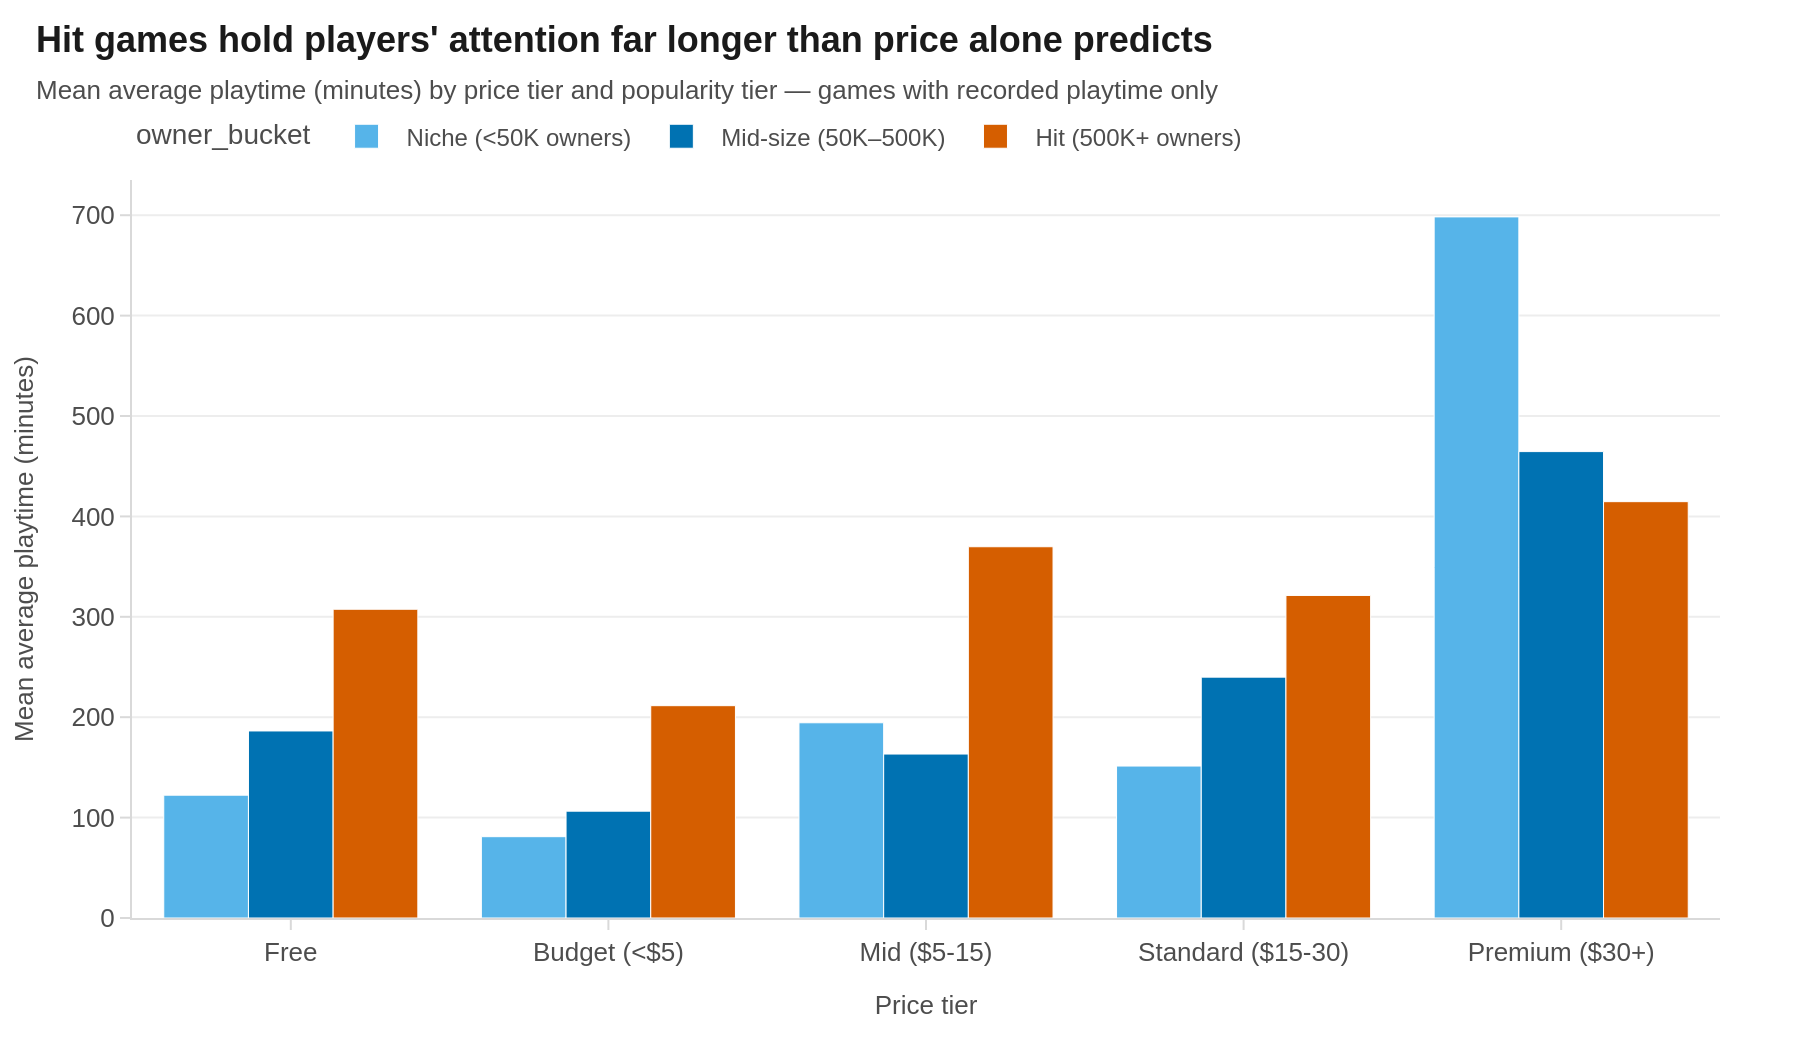

In [6]:
def owner_bucket(cat):
    if pd.isna(cat):
        return np.nan
    if cat in ['0 .. 20,000', '20,000 .. 50,000']:
        return 'Niche (<50K owners)'
    elif cat in ['50,000 .. 100,000', '100,000 .. 200,000', '200,000 .. 500,000']:
        return 'Mid-size (50K–500K)'
    else:
        return 'Hit (500K+ owners)'

df['owner_bucket'] = df['owners'].apply(owner_bucket)
bucket_order = ['Niche (<50K owners)', 'Mid-size (50K–500K)', 'Hit (500K+ owners)']

engagement = (
    df[df['average_playtime'] > 0]
    .groupby(['price_tier', 'owner_bucket'], observed=True)['average_playtime']
    .mean().reset_index()
)

fig = px.bar(
    engagement, x='price_tier', y='average_playtime', color='owner_bucket',
    barmode='group',
    category_orders={'price_tier': list(df['price_tier'].cat.categories), 'owner_bucket': bucket_order},
    color_discrete_sequence=[OI_SKYBLUE, OI_BLUE, OI_VERMILLION]
)
fig = style_fig(
    fig,
    title="Hit games hold players' attention far longer than price alone predicts",
    subtitle="Mean average playtime (minutes) by price tier and popularity tier — games with recorded playtime only",
    xaxis_title="Price tier", yaxis_title="Mean average playtime (minutes)"
)
fig.show()


**Insight:** Popularity — not price — is the dominant driver of playtime. Within every
price tier, "Hit" games rack up far more average playtime than niche titles at the same
price point. Premium-priced niche titles do **not** reliably out-engage cheap niche
titles, undercutting the intuition that "more expensive = more engaging."


### Q4 — Which publishers actually control the market?

**Question:** How concentrated is total estimated ownership among the top publishers —
and does a small number of publishers dominate the long tail of 14,000 catalog owners?


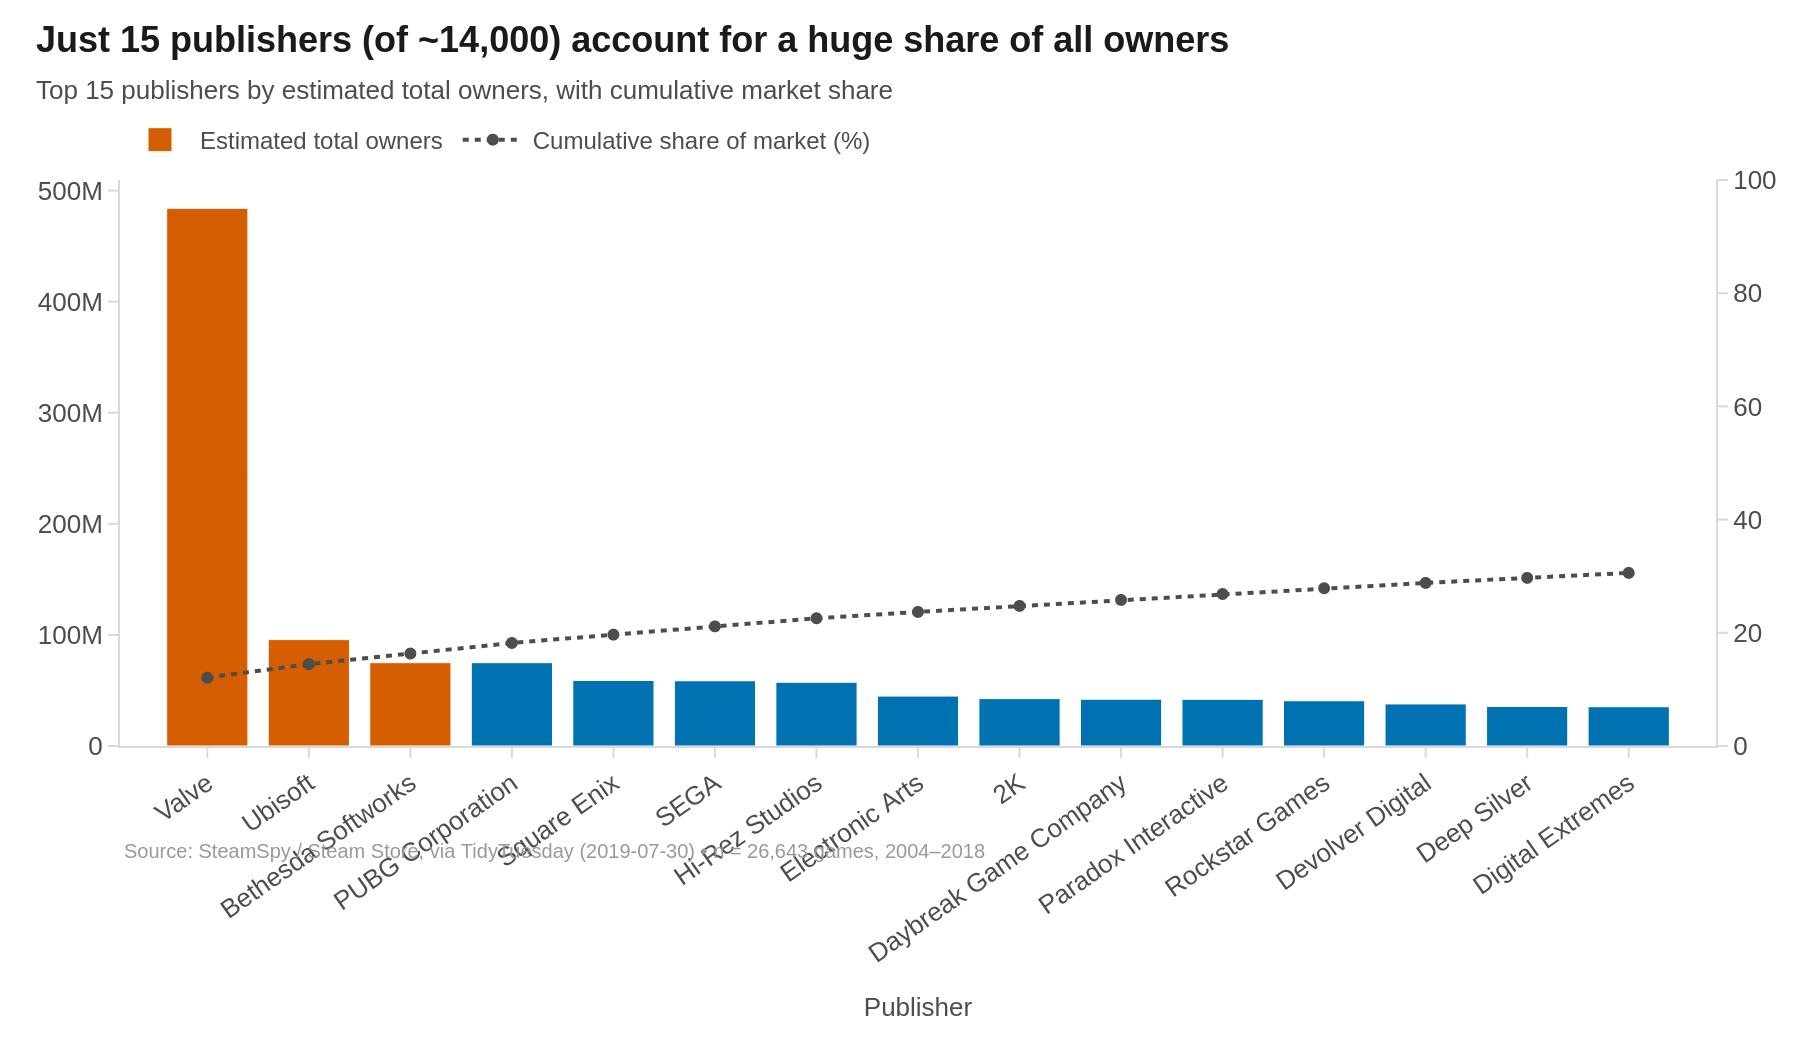

Top 15 publishers alone represent 30.6% of estimated total ownership across 13,933 publishers.


In [7]:
pub_owners = (
    df.groupby('publisher')['owners_est'].sum()
    .sort_values(ascending=False)
)
top15 = pub_owners.head(15).reset_index()
top15.columns = ['publisher', 'total_owners_est']
total_market = pub_owners.sum()
top15['cum_share'] = top15['total_owners_est'].cumsum() / total_market * 100

colors = [OI_VERMILLION if i < 3 else OI_BLUE for i in range(len(top15))]

fig = go.Figure()
fig.add_trace(go.Bar(
    x=top15['publisher'], y=top15['total_owners_est'],
    marker_color=colors, name='Estimated total owners', yaxis='y1'
))
fig.add_trace(go.Scatter(
    x=top15['publisher'], y=top15['cum_share'],
    name='Cumulative share of market (%)', mode='lines+markers',
    line=dict(color=GREY_DARK, width=2, dash='dot'), marker=dict(size=6), yaxis='y2'
))
fig.update_layout(
    yaxis=dict(title='Estimated total owners (sum across catalog)'),
    yaxis2=dict(title='Cumulative % of total market', overlaying='y', side='right',
                showgrid=False, range=[0, 100]),
    xaxis=dict(tickangle=-35),
)
fig = style_fig(
    fig,
    title="Just 15 publishers (of ~14,000) account for a huge share of all owners",
    subtitle="Top 15 publishers by estimated total owners, with cumulative market share",
    xaxis_title="Publisher", show_grid_y=False
)
fig.show()
print(f"Top 15 publishers alone represent {top15['cum_share'].iloc[-1]:.1f}% of estimated total ownership across {df['publisher'].nunique():,} publishers.")


**Insight:** Valve, along with a handful of major publishers, accounts for a
disproportionate share of total estimated ownership. This is a classic long-tail market:
tens of thousands of small publishers each hold a sliver of the pie, while a handful of
incumbents (helped by Valve's own first-party titles and platform advantages) dominate
total reach.


### Q5 — Does critical acclaim translate into longer play sessions?

**Question:** Among the ~2,850 games with a recorded Metacritic score, does a higher
score predict meaningfully more playtime, or does the relationship plateau?


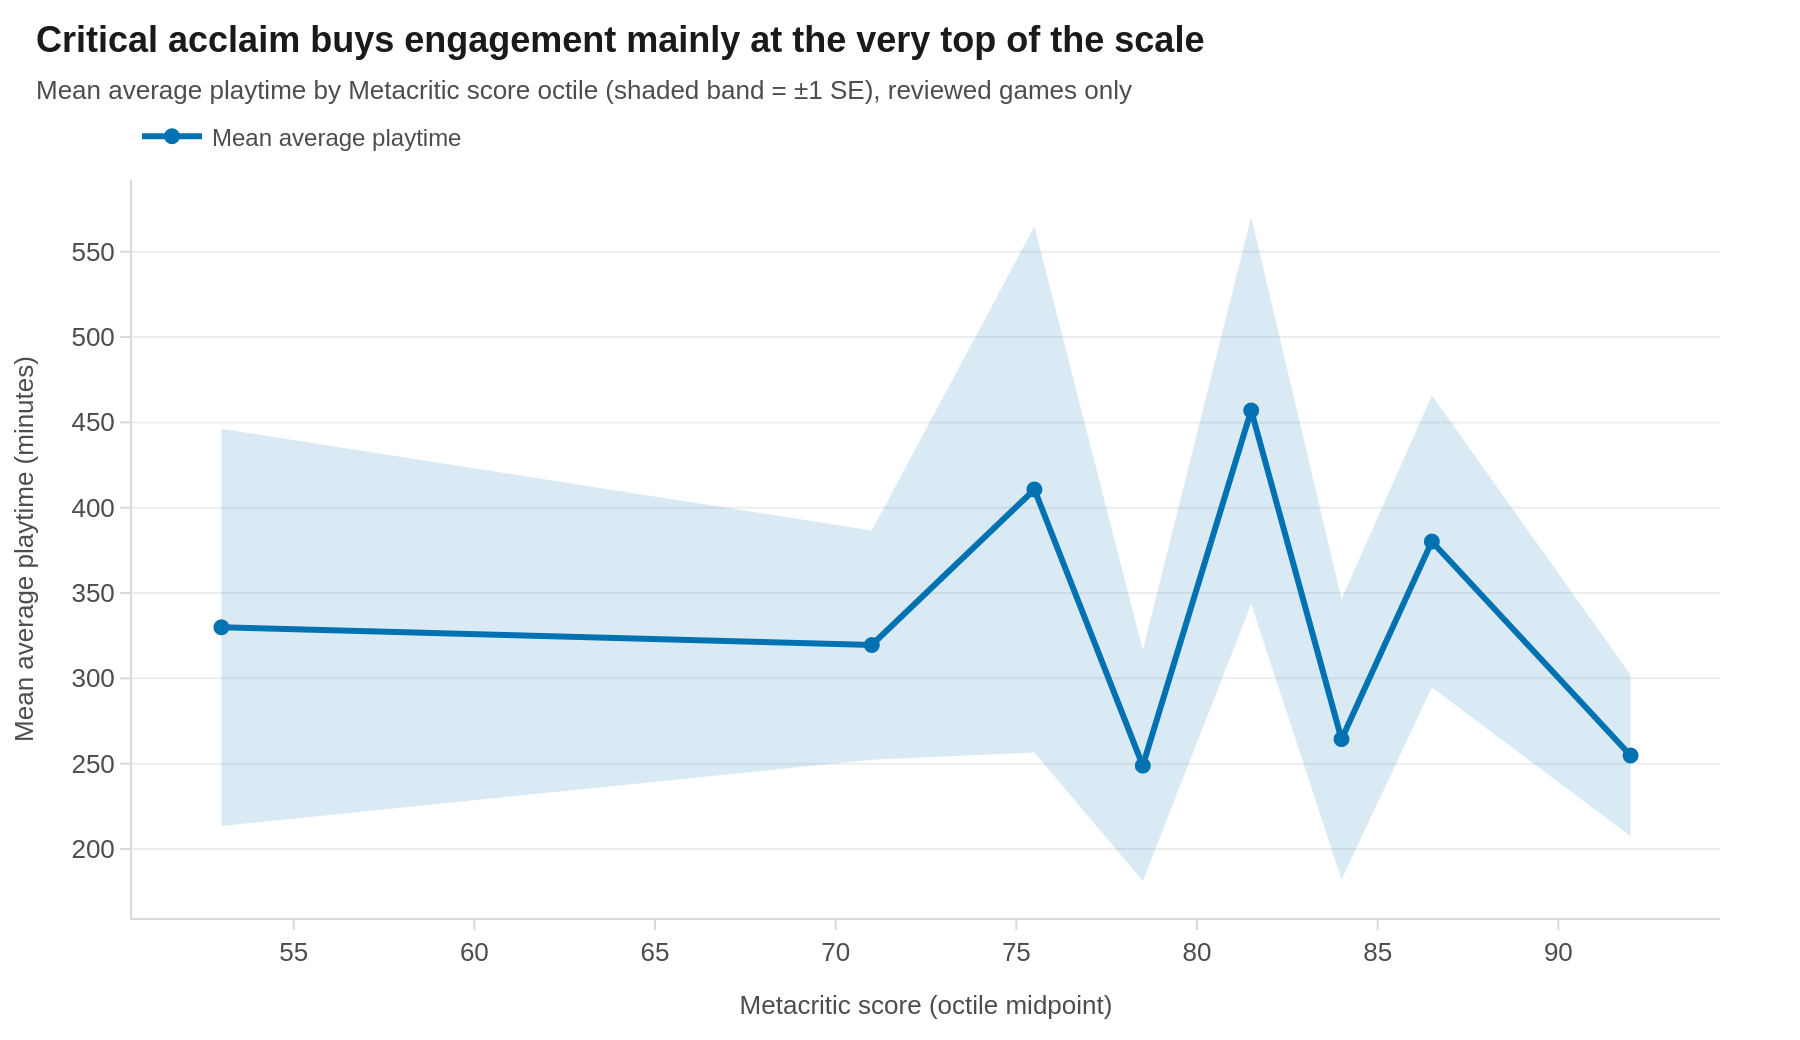

In [8]:
reviewed = df[df['has_critic_score'] & (df['average_playtime'] > 0)].copy()
reviewed['score_decile'] = pd.qcut(reviewed['metascore'], 8, duplicates='drop')
decile_stats = reviewed.groupby('score_decile', observed=True)['average_playtime'].agg(['mean', 'std', 'count']).reset_index()
decile_stats['score_mid'] = decile_stats['score_decile'].apply(lambda iv: iv.mid)
decile_stats['se'] = decile_stats['std'] / np.sqrt(decile_stats['count'])

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=decile_stats['score_mid'], y=decile_stats['mean'] + decile_stats['se'],
    mode='lines', line=dict(width=0), showlegend=False, hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=decile_stats['score_mid'], y=decile_stats['mean'] - decile_stats['se'],
    mode='lines', line=dict(width=0), fill='tonexty',
    fillcolor='rgba(0,114,178,0.15)', showlegend=False, hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=decile_stats['score_mid'], y=decile_stats['mean'],
    mode='lines+markers', line=dict(color=OI_BLUE, width=3), marker=dict(size=8),
    name='Mean average playtime'
))
fig = style_fig(
    fig,
    title="Critical acclaim buys engagement mainly at the very top of the scale",
    subtitle="Mean average playtime by Metacritic score octile (shaded band = ±1 SE), reviewed games only",
    xaxis_title="Metacritic score (octile midpoint)", yaxis_title="Mean average playtime (minutes)"
)
fig.show()


**Insight:** Playtime stays fairly flat across the low-to-mid score range and only rises
sharply for the highest-scoring games (roughly 85+). This suggests critical acclaim is a
weak predictor of engagement until a game crosses into "must-play" territory — below
that, other factors (genre, multiplayer design, marketing) likely matter more than score.


### Q6 — Are there "hidden gems": critically loved but commercially invisible?

**Question:** Where do games fall on the quality-vs-reach plane, and can we identify a
cluster of high-metascore, low-ownership "hidden gems" versus low-score commercial hits?


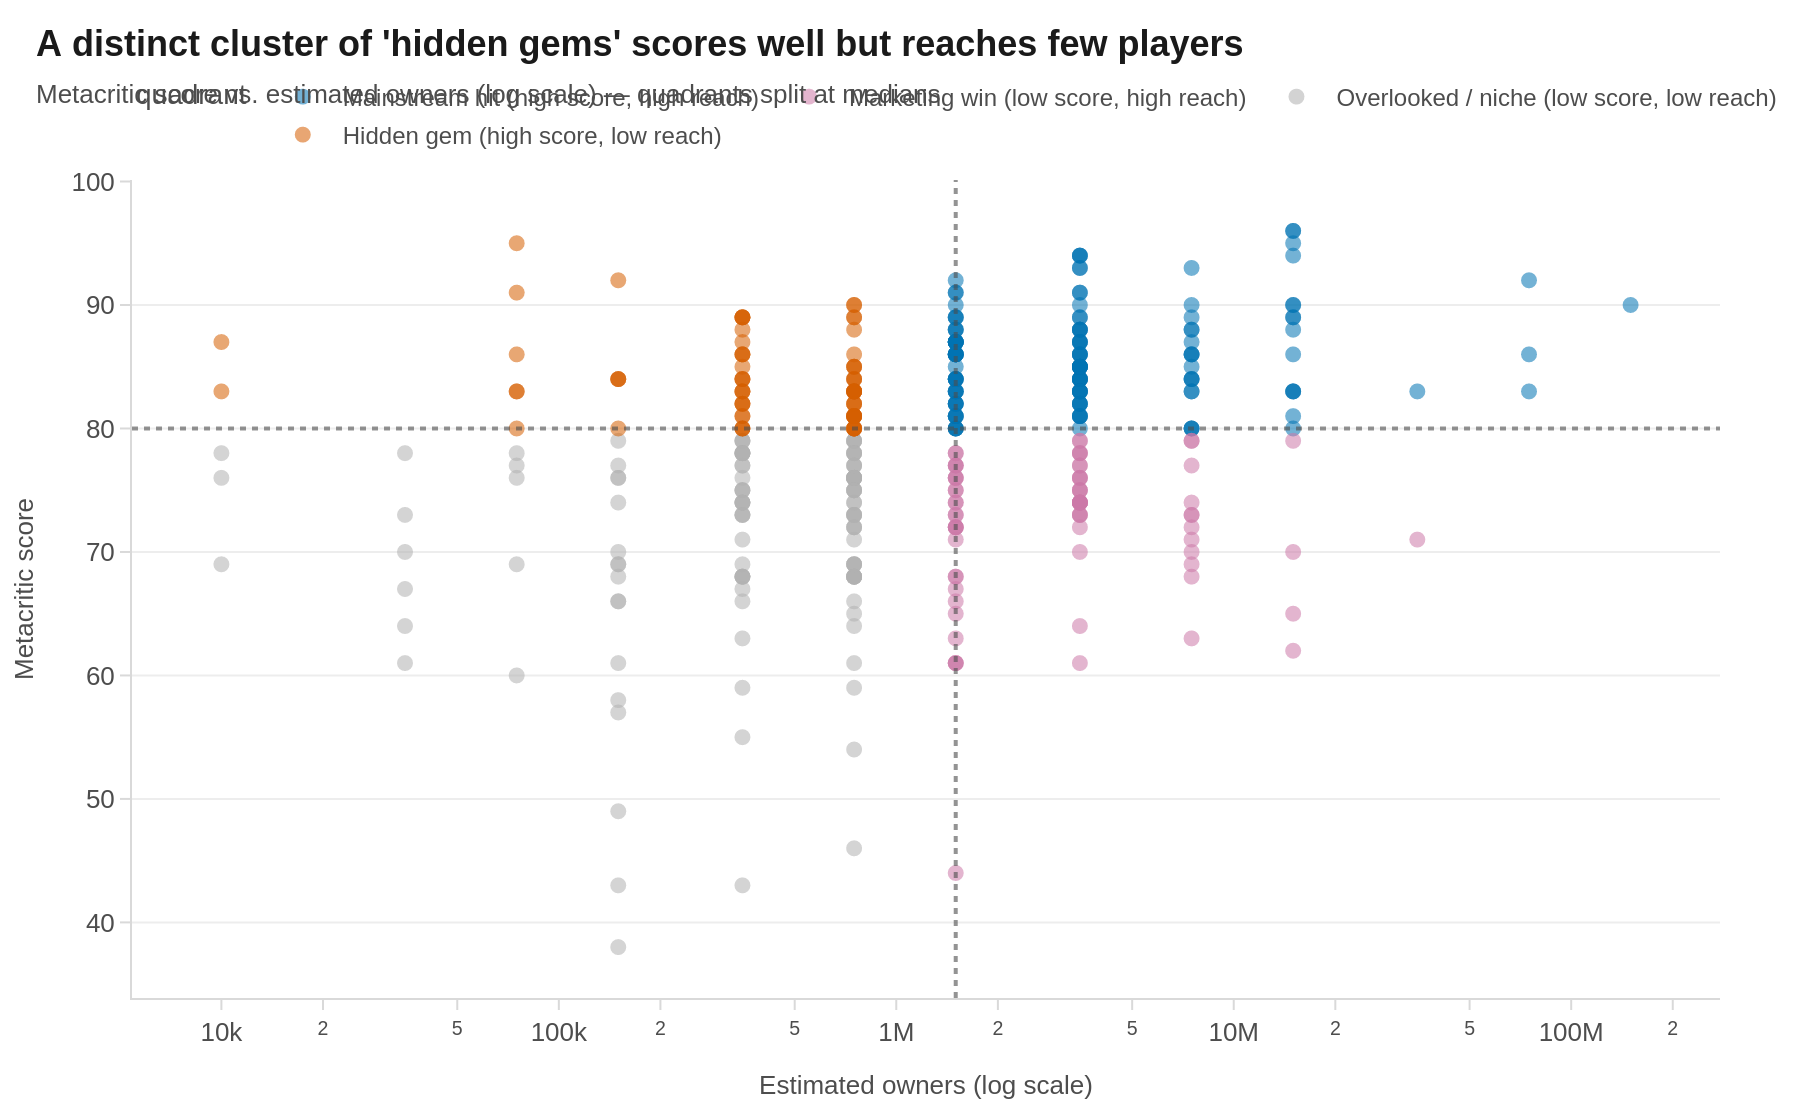

69 reviewed games (17.7%) are 'hidden gems' — above-median score, below-median reach.


In [9]:
quad = reviewed.copy()
quad = quad[quad['owners_est'] > 0]
score_med = quad['metascore'].median()
owners_med = quad['owners_est'].median()

def quadrant(row):
    if row['metascore'] >= score_med and row['owners_est'] < owners_med:
        return 'Hidden gem (high score, low reach)'
    elif row['metascore'] >= score_med and row['owners_est'] >= owners_med:
        return 'Mainstream hit (high score, high reach)'
    elif row['metascore'] < score_med and row['owners_est'] >= owners_med:
        return 'Marketing win (low score, high reach)'
    else:
        return 'Overlooked / niche (low score, low reach)'

quad['quadrant'] = quad.apply(quadrant, axis=1)

fig = px.scatter(
    quad, x='owners_est', y='metascore', color='quadrant',
    log_x=True, hover_name='game', opacity=0.55,
    color_discrete_map={
        'Hidden gem (high score, low reach)': OI_VERMILLION,
        'Mainstream hit (high score, high reach)': OI_BLUE,
        'Marketing win (low score, high reach)': OI_PURPLE,
        'Overlooked / niche (low score, low reach)': GREY,
    }
)
fig.add_vline(x=owners_med, line_dash='dot', line_color=GREY_DARK, opacity=0.6)
fig.add_hline(y=score_med, line_dash='dot', line_color=GREY_DARK, opacity=0.6)
fig = style_fig(
    fig,
    title="A distinct cluster of 'hidden gems' scores well but reaches few players",
    subtitle="Metacritic score vs. estimated owners (log scale) — quadrants split at medians",
    xaxis_title="Estimated owners (log scale)", yaxis_title="Metacritic score", height=560
)
fig.update_traces(marker=dict(size=8))
fig.show()
n_gems = (quad['quadrant'] == 'Hidden gem (high score, low reach)').sum()
print(f"{n_gems:,} reviewed games ({n_gems/len(quad)*100:.1f}%) are 'hidden gems' — above-median score, below-median reach.")


**Insight:** A meaningful share of critically strong games never find a large audience —
Steam's discovery problem is real. Conversely, the "marketing win" quadrant (popular
despite mediocre reviews) is thinner, suggesting reach on Steam correlates with quality
more often than not, but quality alone is far from sufficient for reach.


### Q7 — Do prolific developers sustain quality as they scale output?

**Question:** As a developer's catalog grows from a single game to dozens, does their
average critical reception hold steady, improve, or decline?


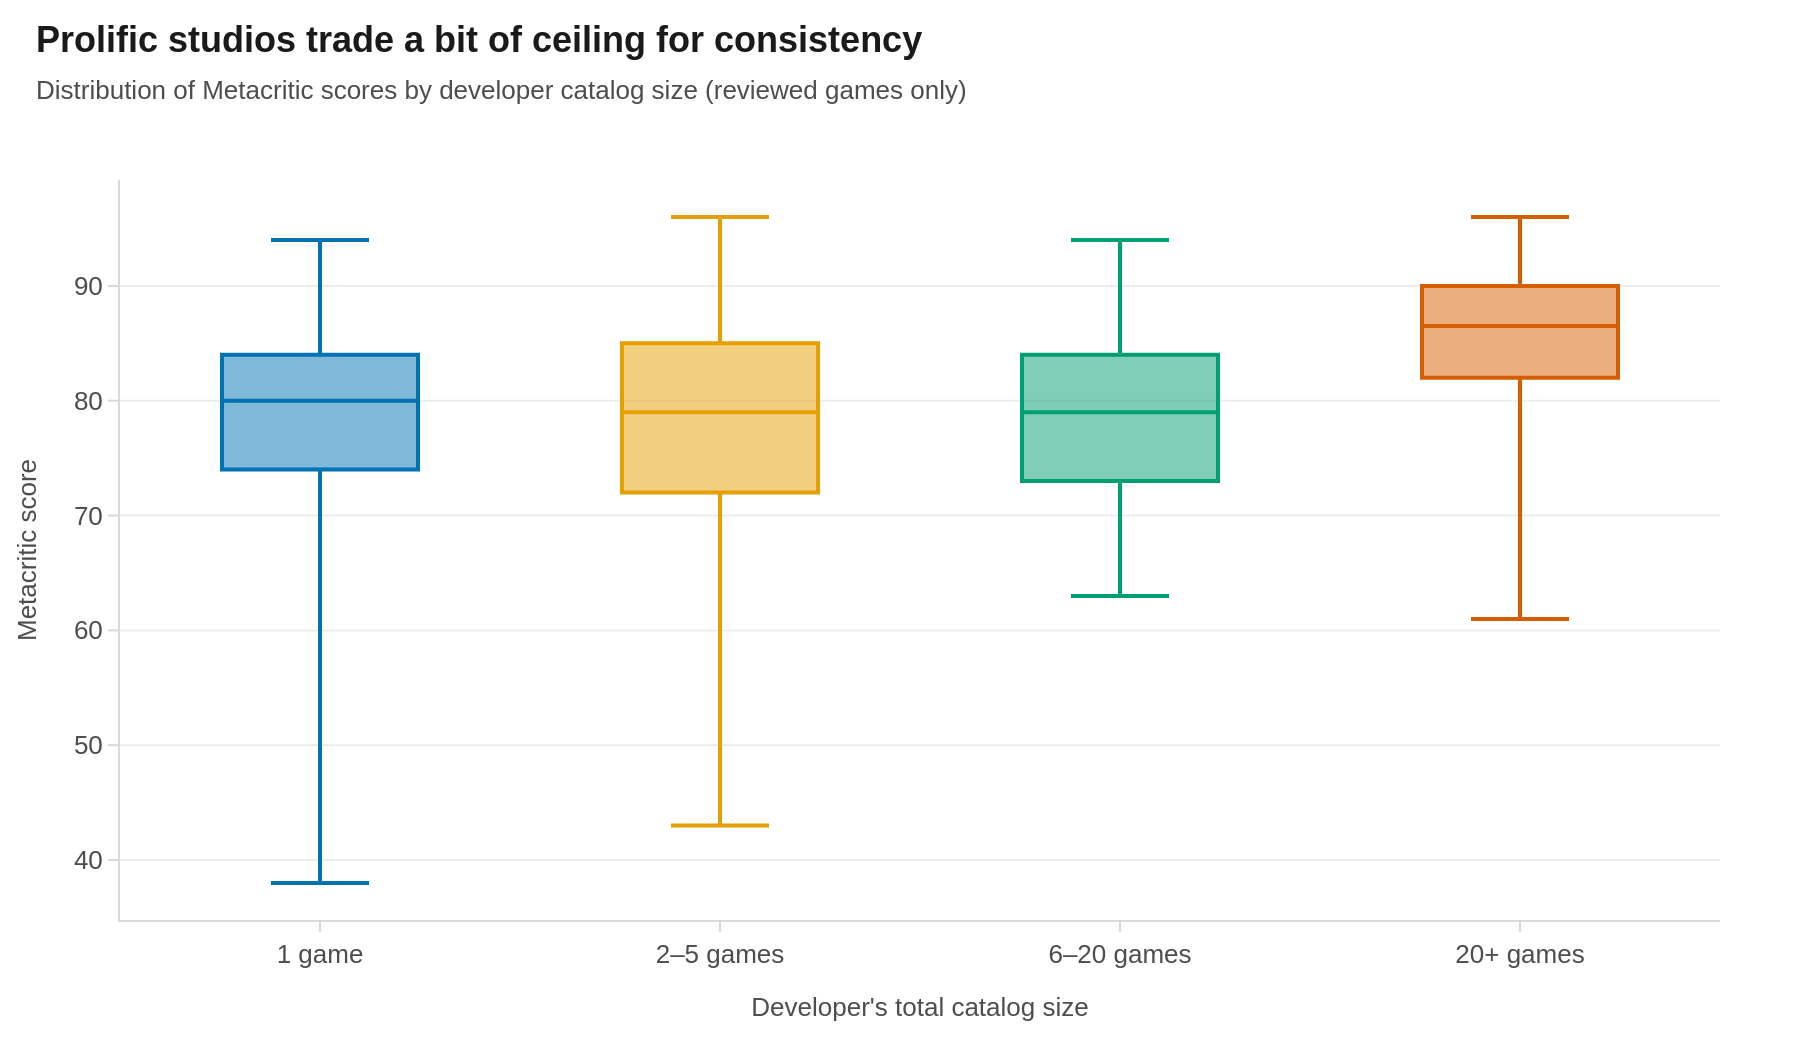

                 mean  median  count
dev_bucket                          
1 game      78.431034    80.0    116
2–5 games   77.462025    79.0    158
6–20 games  78.822222    79.0     90
20+ games   84.307692    86.5     26


In [10]:
def catalog_bucket(n):
    if n == 1:
        return '1 game'
    elif n <= 5:
        return '2–5 games'
    elif n <= 20:
        return '6–20 games'
    else:
        return '20+ games'

reviewed['dev_bucket'] = reviewed['developer_catalog_size'].apply(catalog_bucket)
bucket_order2 = ['1 game', '2–5 games', '6–20 games', '20+ games']

fig = px.box(
    reviewed, x='dev_bucket', y='metascore', color='dev_bucket',
    category_orders={'dev_bucket': bucket_order2},
    color_discrete_sequence=CATEGORY_SEQUENCE,
    points=False
)
fig.update_layout(showlegend=False)
fig = style_fig(
    fig,
    title="Prolific studios trade a bit of ceiling for consistency",
    subtitle="Distribution of Metacritic scores by developer catalog size (reviewed games only)",
    xaxis_title="Developer's total catalog size", yaxis_title="Metacritic score"
)
fig.show()
print(reviewed.groupby('dev_bucket', observed=True)['metascore'].agg(['mean', 'median', 'count']).reindex(bucket_order2))


**Insight:** Median scores are broadly similar across catalog sizes, but one-hit
developers show the widest spread — including both the very best and very worst scores
in the dataset. Highly prolific studios (20+ games) rarely bomb but also rarely reach the
absolute top of the score distribution: scale buys consistency, not necessarily
excellence.


### Q8 — Which price tiers produce the most polarizing player experiences?

**Question:** Using the gap between mean and median playtime as a "polarization" signal
(a big gap means a small group of hardcore players is dragging the average up), which
price tiers show the most divided audiences?


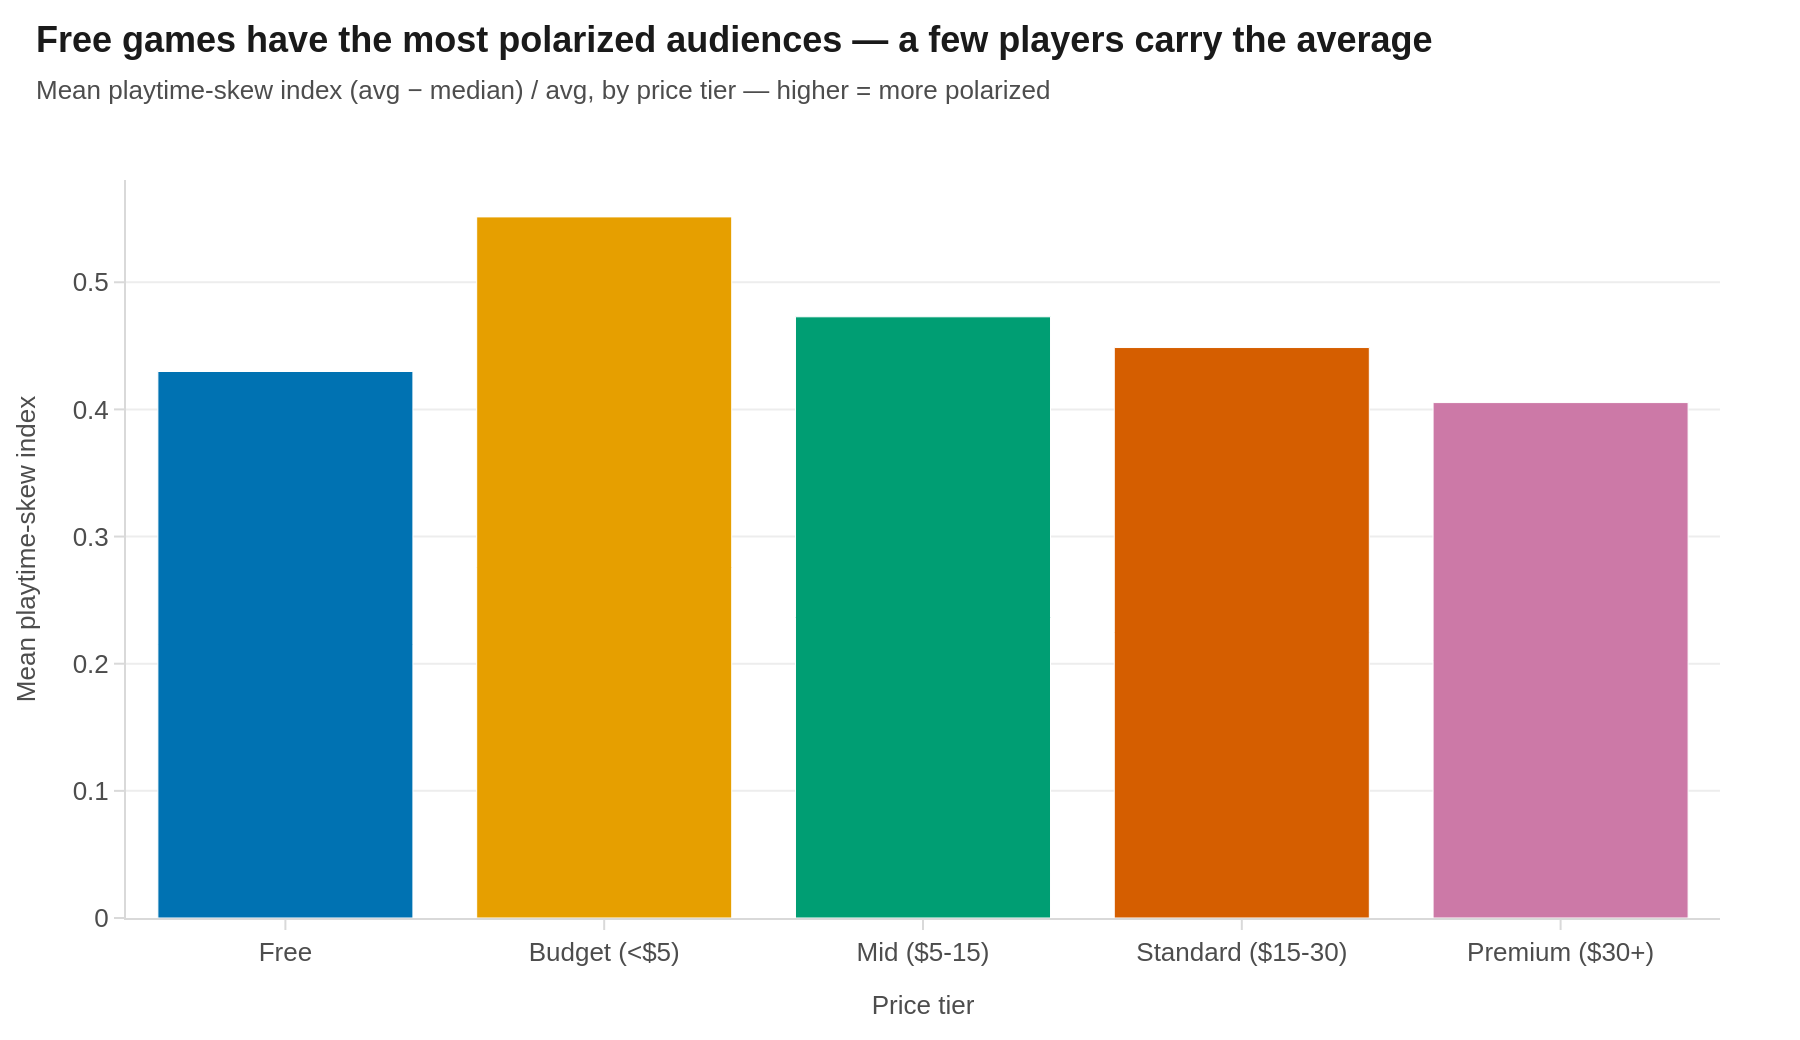

In [11]:
skew_df = df[(df['average_playtime'] > 0) & df['playtime_skew'].notna()]
skew_stats = skew_df.groupby('price_tier', observed=True)['playtime_skew'].mean().reset_index()

fig = px.bar(
    skew_stats, x='price_tier', y='playtime_skew',
    color='price_tier', color_discrete_sequence=CATEGORY_SEQUENCE
)
fig.update_layout(showlegend=False)
fig = style_fig(
    fig,
    title="Free games have the most polarized audiences — a few players carry the average",
    subtitle="Mean playtime-skew index (avg − median) / avg, by price tier — higher = more polarized",
    xaxis_title="Price tier", yaxis_title="Mean playtime-skew index"
)
fig.show()


**Insight:** Free-to-play titles show the highest polarization: most players sample
briefly while a committed core logs enormous hours, pulling the mean well above the
median. Paid tiers show progressively less skew — buyers who pay upfront tend to play
more uniformly, consistent with reduced "drive-by" sampling.


### Q9 — Have game titles gotten shorter, and has sequel-labeling changed over time?

**Question:** As the catalog shifted toward indie titles, did naming conventions change —
shorter titles, fewer explicit sequel/edition markers?


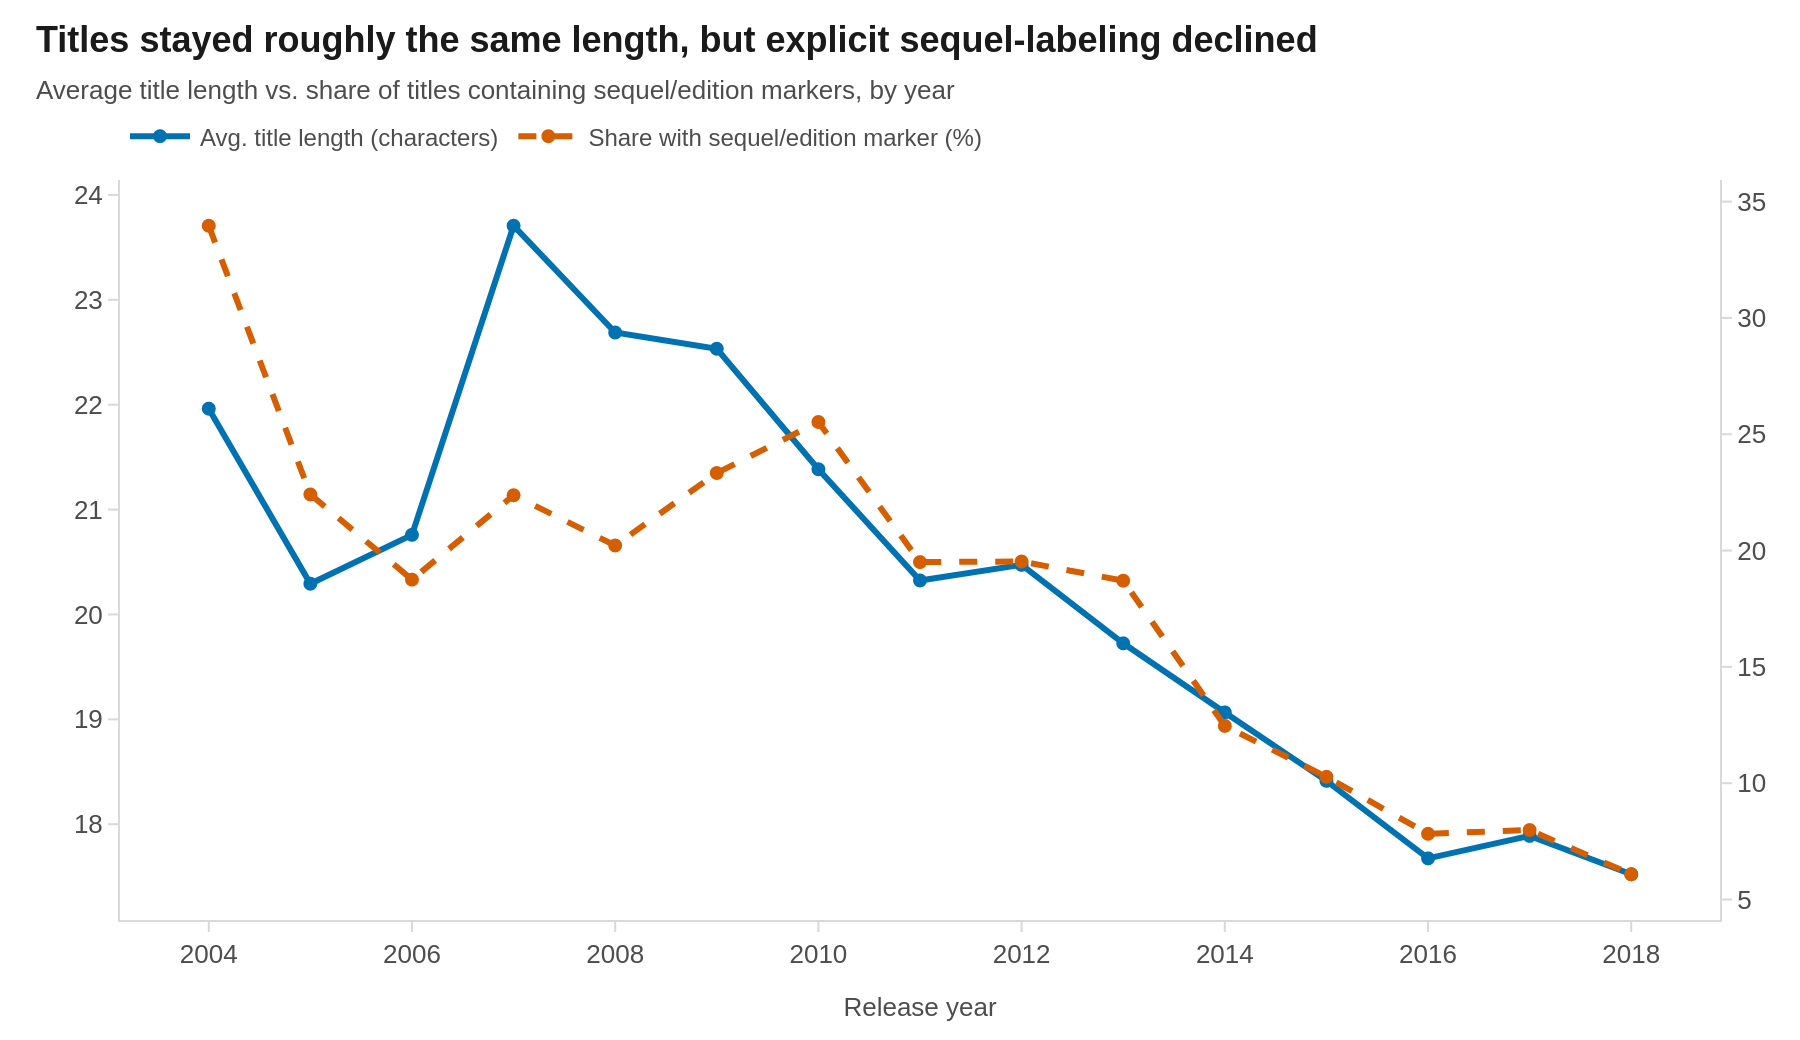

In [12]:
title_trend = df.groupby('release_year').agg(
    avg_title_len=('title_length_chars', 'mean'),
    sequel_share=('is_sequel_like', lambda s: s.mean() * 100)
).reset_index()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=title_trend['release_year'], y=title_trend['avg_title_len'],
    name='Avg. title length (characters)', mode='lines+markers',
    line=dict(color=OI_BLUE, width=3), marker=dict(size=7), yaxis='y1'
))
fig.add_trace(go.Scatter(
    x=title_trend['release_year'], y=title_trend['sequel_share'],
    name='Share with sequel/edition marker (%)', mode='lines+markers',
    line=dict(color=OI_VERMILLION, width=3, dash='dash'), marker=dict(size=7), yaxis='y2'
))
fig.update_layout(
    yaxis=dict(title='Average title length (characters)'),
    yaxis2=dict(title='Share of titles with a sequel/edition marker (%)', overlaying='y', side='right', showgrid=False),
)
fig = style_fig(
    fig,
    title="Titles stayed roughly the same length, but explicit sequel-labeling declined",
    subtitle="Average title length vs. share of titles containing sequel/edition markers, by year",
    xaxis_title="Release year", show_grid_y=False
)
fig.show()


**Insight:** Title length is remarkably stable across 15 years, but the share of titles
carrying an explicit sequel or edition marker (e.g. "II", "Remastered") declines as the
catalog shifts toward original indie IP rather than franchise sequels and remasters from
established publishers.


### Q10 — Do "sequel-like" titles actually sell better, and does that hold at every price point?

**Question:** Comparing sequel/edition-flagged titles to original titles, is there a
commercial advantage — and does it persist once we control for price tier?


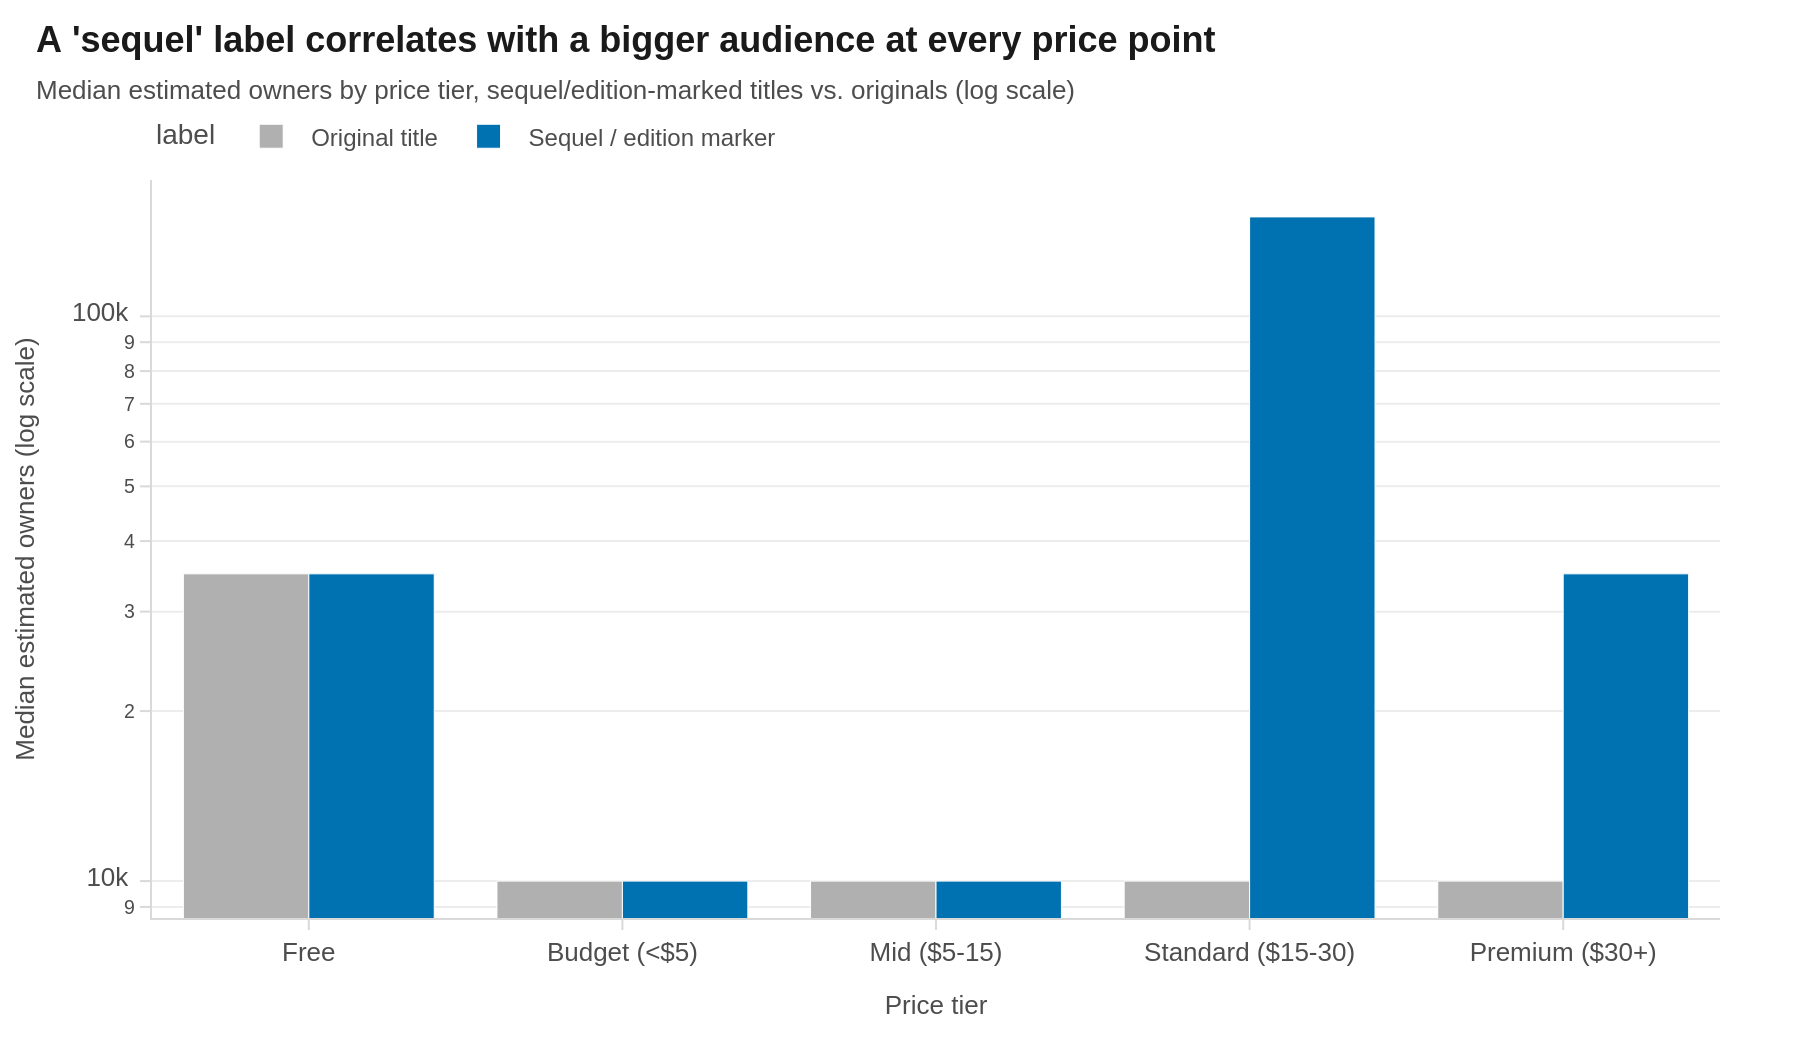

In [13]:
seq_compare = (
    df[df['owners_est'] > 0]
    .groupby(['price_tier', 'is_sequel_like'], observed=True)['owners_est']
    .median().reset_index()
)
seq_compare['label'] = seq_compare['is_sequel_like'].map({True: 'Sequel / edition marker', False: 'Original title'})

fig = px.bar(
    seq_compare, x='price_tier', y='owners_est', color='label',
    barmode='group', log_y=True,
    category_orders={'price_tier': list(df['price_tier'].cat.categories)},
    color_discrete_sequence=[GREY, OI_BLUE]
)
fig = style_fig(
    fig,
    title="A 'sequel' label correlates with a bigger audience at every price point",
    subtitle="Median estimated owners by price tier, sequel/edition-marked titles vs. originals (log scale)",
    xaxis_title="Price tier", yaxis_title="Median estimated owners (log scale)"
)
fig.show()


**Insight:** At every price tier, titles carrying a sequel or edition marker reach a
larger median audience than original titles — brand recognition and an established
fanbase appear to provide a persistent commercial edge, regardless of how the game is
priced.


### Q11 — Is the market "flooding" with low-visibility titles over time?

**Question:** What share of each year's releases land in the very lowest ownership
bracket (under 20,000 owners), and how has that share trended as competition increased?


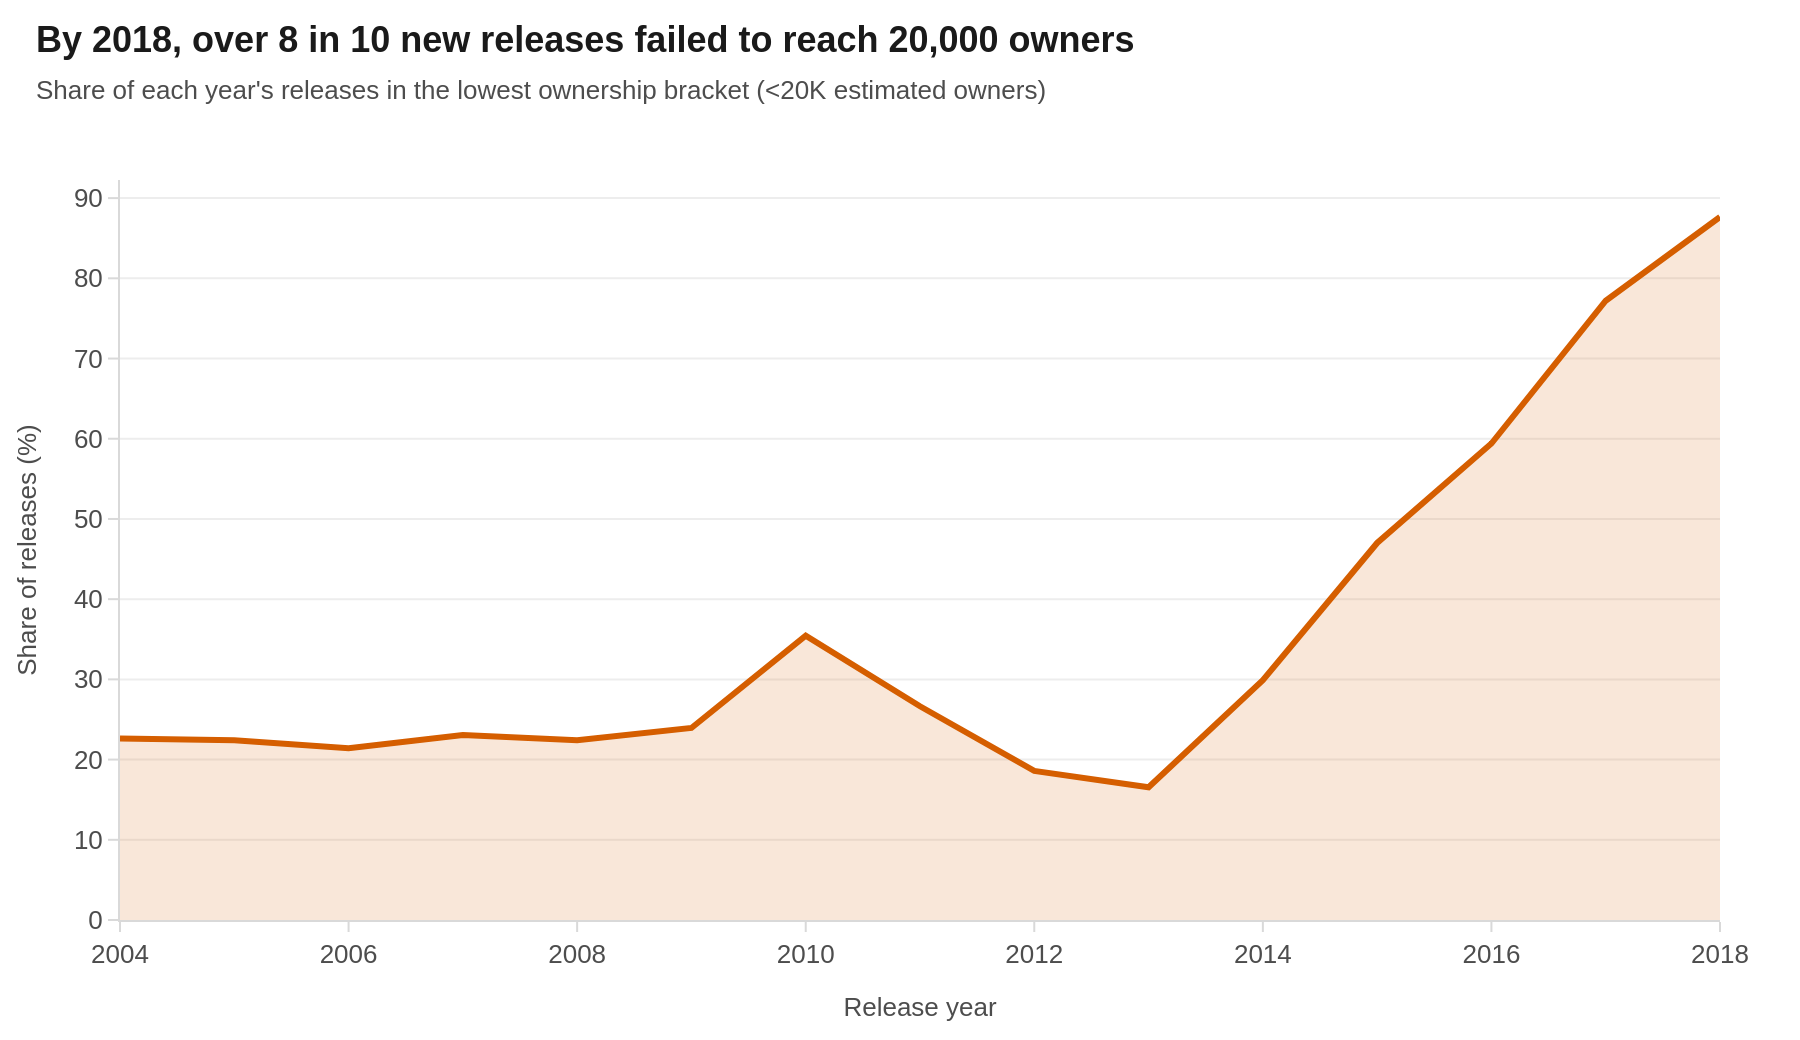

In [14]:
flood = df.groupby('release_year').apply(
    lambda g: (g['owners'] == '0 .. 20,000').mean() * 100, include_groups=False
).reset_index(name='low_owner_share')

fig = px.area(
    flood, x='release_year', y='low_owner_share',
    color_discrete_sequence=[OI_VERMILLION]
)
fig.update_traces(line=dict(width=3), fillcolor='rgba(213,94,0,0.15)')
fig = style_fig(
    fig,
    title="By 2018, over 8 in 10 new releases failed to reach 20,000 owners",
    subtitle="Share of each year's releases in the lowest ownership bracket (<20K estimated owners)",
    xaxis_title="Release year", yaxis_title="Share of releases (%)"
)
fig.show()


**Insight:** The share of releases stuck in the lowest ownership bracket rises sharply
after ~2014, coinciding with Steam Greenlight/Direct massively expanding the number of
titles published per year (see Q1). More releases chasing a similarly sized player base
means the median new game is increasingly unlikely to find a large audience.


### Q12 — Where does the bulk of the catalog actually sit, price vs. popularity?

**Question:** Combining price tier and ownership bracket into a single view, where does
the Steam catalog concentrate — and where are the "sweet spots" that are rare?


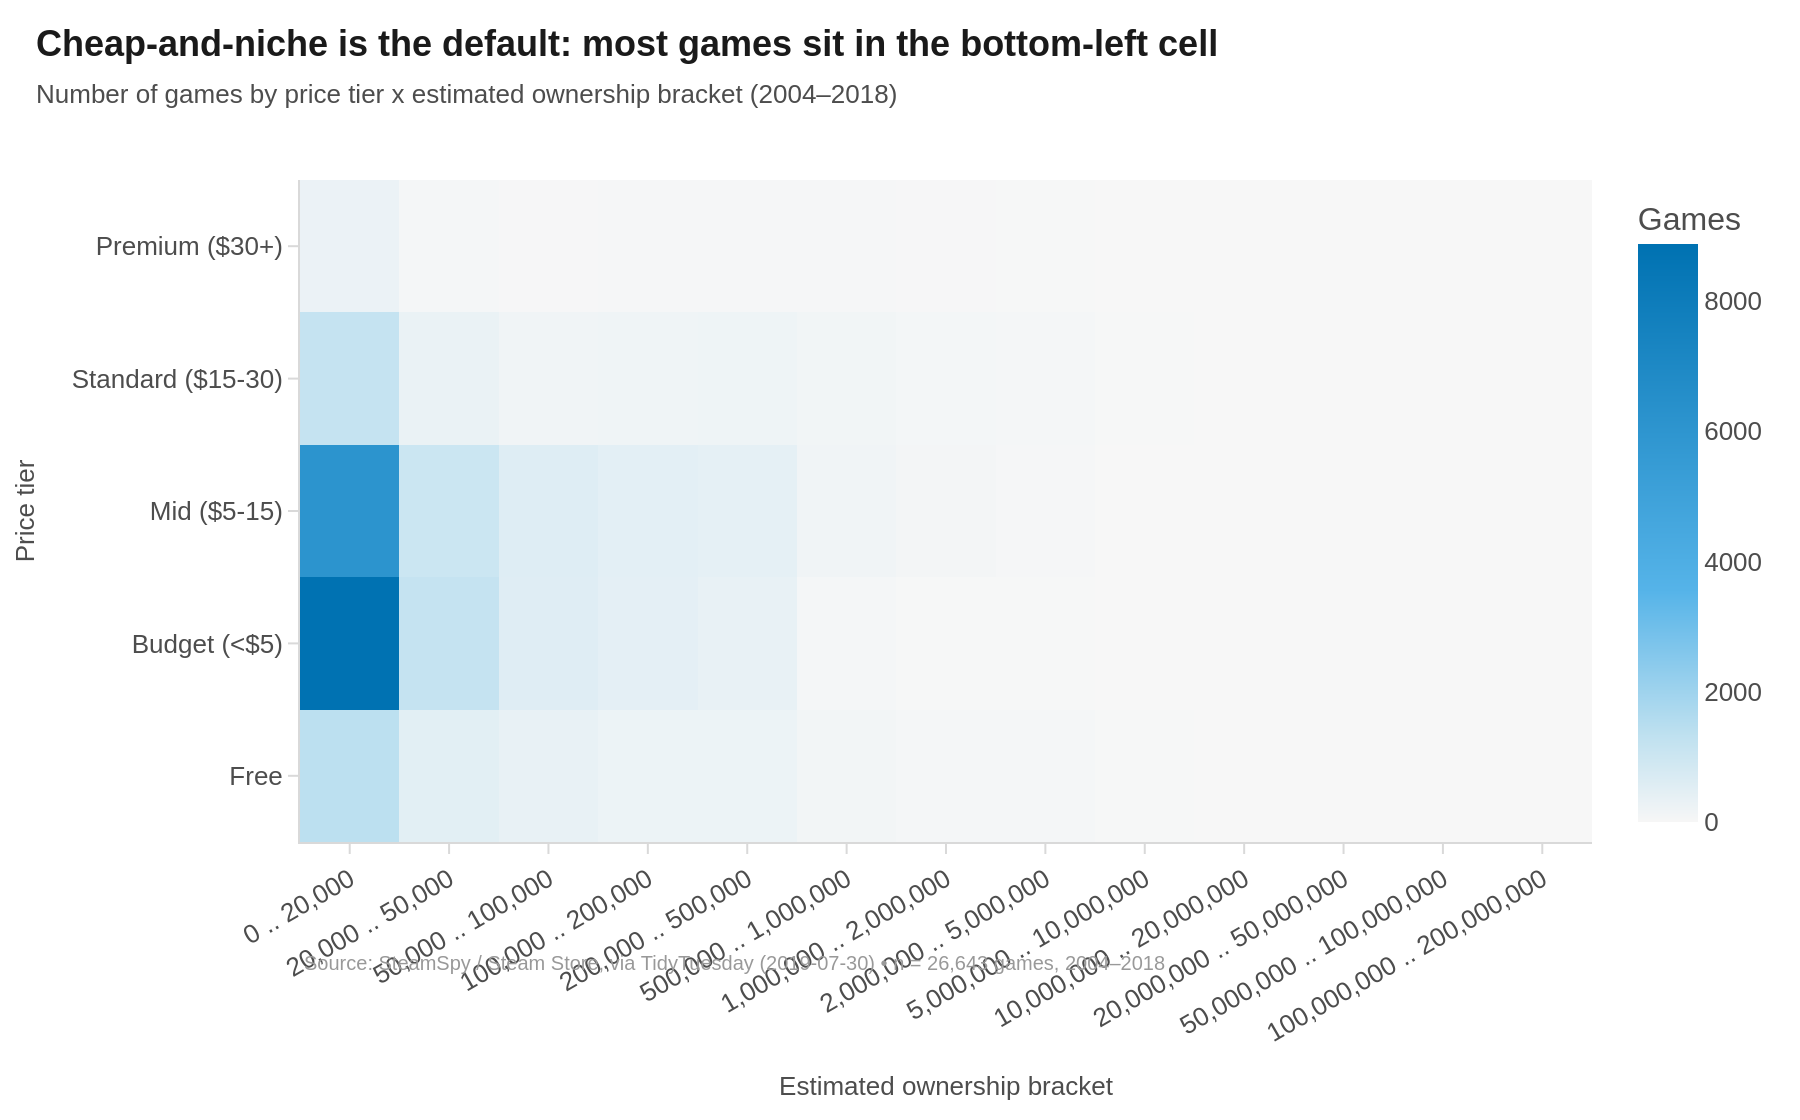

In [15]:
heat = df.groupby(['price_tier', 'owners'], observed=True).size().reset_index(name='count')
heat_pivot = heat.pivot(index='price_tier', columns='owners', values='count').fillna(0)
heat_pivot = heat_pivot.reindex(index=list(df['price_tier'].cat.categories))

fig = go.Figure(data=go.Heatmap(
    z=heat_pivot.values,
    x=[str(c) for c in heat_pivot.columns],
    y=[str(i) for i in heat_pivot.index],
    colorscale=[[0, '#F7F7F7'], [0.15, '#BFE1F0'], [0.4, '#56B4E9'], [1, '#0072B2']],
    colorbar=dict(title='Games'),
    hovertemplate='Price tier: %{y}<br>Owners: %{x}<br>Games: %{z:,.0f}<extra></extra>'
))
fig = style_fig(
    fig,
    title="Cheap-and-niche is the default: most games sit in the bottom-left cell",
    subtitle="Number of games by price tier x estimated ownership bracket (2004–2018)",
    xaxis_title="Estimated ownership bracket", yaxis_title="Price tier", height=560
)
fig.update_xaxes(tickangle=-30)
fig.show()


**Insight:** The overwhelming majority of the catalog sits in the "Budget/Free x under
20,000 owners" cell — confirming the long-tail structure seen throughout this analysis.
Commercial hits (500K+ owners) appear across every price tier, but they are rare outliers
against a backdrop dominated by inexpensive, low-visibility releases.


## 3. Conclusions

Across twelve angles on the same 26,643-game catalog, a consistent story emerges:

1. **The Steam market industrialized.** Annual releases grew ~30x from 2004 to 2018 while
   median prices fell by more than half — the platform shifted from a curated, premium-priced
   storefront to an open, high-volume, budget-priced marketplace.
2. **Popularity — not price — drives engagement.** Hit games out-engage niche titles at
   every price point; paying more does not reliably buy more playtime.
3. **The market is winner-take-most.** A handful of publishers control a large share of
   total ownership, sequel/edition-labeled titles command a persistent commercial premium,
   and "hidden gems" (high quality, low reach) are common — Steam's discovery problem is real.
4. **Abundance has a cost.** As releases multiplied post-2014, the share of games that
   never reach even 20,000 owners rose sharply, and free-to-play titles show the most
   polarized (winner-take-most) playtime distributions of any price tier.

**Limitations:** Ownership and playtime figures are SteamSpy estimates (subject to API
changes and privacy-setting biases), Metacritic coverage is sparse (~10.7% of titles), and
the snapshot ends in 2019 — pre-dating more recent shifts in Steam's discovery algorithm
and the further indie-market expansion of the 2020s.
